In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("SOC_RF_Tabular")

<Experiment: artifact_location='/Users/aditibharadwaj/Documents/experiqs/MH_SOC/mlruns/1', creation_time=1781681119053, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781681119053, lifecycle_stage='active', name='SOC_RF_Tabular', tags={}, trace_location=None, workspace='default'>

In [3]:
df=pd.read_csv('cleaned_MH_OC.csv')

In [4]:
embed_df = pd.read_csv("alphaearth_embeddings.csv")
df_embed = df.merge(embed_df,on='fid',how='left')

In [5]:
# target
target = "OC_group_median"

# remove leakage columns
leakage_cols = [
    'OC','OC_log1p','OC_bin',
    'duplicate_OC_conflict_class'
]

metadata_cols = [
    'fid','date','tile_id','tile_date',
    'source_csv','source_s2_chunk',
    'bare_soil_reason','S2_bare_soil_filter_reason',
    'spatial_qc_reason','village'
]

soil_property_cols = [
    'sand',
    'silt',
    'clay',
    'pH',
    'EC',
    'BD',
    'N',
    'P',
    'K',
    'SOC',
    'OC',
    'OC_group',
    'OC_group_median',
    'CEC',
    'moisture',
    'bulk_density'
]

drop_cols = (
    leakage_cols +
    metadata_cols +
    soil_property_cols +
    [target]
)

# keep only usable columns
X = df_embed.drop(columns=drop_cols, errors="ignore")
y = df_embed[target]

print(X.shape)

(281250, 207)


In [6]:
from sklearn.preprocessing import LabelEncoder

cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.fillna(X.median(numeric_only=True))

print(X.shape)

(281250, 207)


In [7]:
embedding_cols = [
    c for c in embed_df.columns
    if c != "fid"
]

print("No. embeddings:", len(embedding_cols))

No. embeddings: 65


In [8]:
X_embed = X[embedding_cols]

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

with mlflow.start_run(run_name="AlphaEarth_Embeddings_RF") as embed_run:

    X_train, X_test, y_train, y_test = train_test_split(
        X_embed,
        y,
        test_size=0.2,
        random_state=42
    )

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("R2:", r2)
    print("RMSE:", rmse)

    mlflow.log_param("feature_set", "AlphaEarth_Embeddings")
    mlflow.log_param("n_features", X_embed.shape[1])
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("max_depth", None)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("R2", r2)
    mlflow.log_metric("RMSE", rmse)

    mlflow.sklearn.log_model(model, "model")

embed_run_id = embed_run.info.run_id

2026/06/17 14:43:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/17 14:43:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


R2: 0.5543475849739593
RMSE: 0.2819924766512583


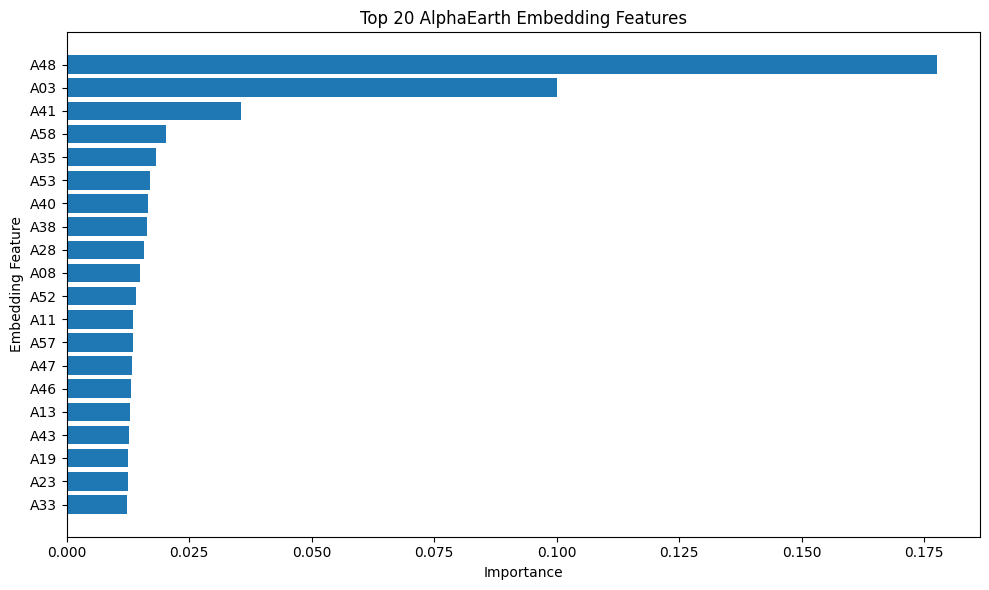

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

embed_importance = pd.DataFrame({
    "Feature": X_embed.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(
    embed_importance.head(20)["Feature"][::-1],
    embed_importance.head(20)["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Embedding Feature")
plt.title("Top 20 AlphaEarth Embedding Features")
plt.tight_layout()

plt.savefig("alphaearth_embed_importance.png", bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=embed_run_id):
    mlflow.log_artifact("alphaearth_embed_importance.png")

In [ ]:
X_all = X.copy()

with mlflow.start_run(run_name="AlphaEarth_Combined_RF") as combined_run:

    X_train, X_test, y_train, y_test = train_test_split(
        X_all,
        y,
        test_size=0.2,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    print("Combined Features R2:", r2)
    print("Combined Features RMSE:", rmse)

    mlflow.log_param("feature_set", "AlphaEarth_Combined")
    mlflow.log_param("n_features", X_all.shape[1])
    mlflow.log_param("n_estimators", 500)
    mlflow.log_param("max_depth", None)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("R2", r2)
    mlflow.log_metric("RMSE", rmse)

    mlflow.sklearn.log_model(model, "model")

combined_run_id = combined_run.info.run_id

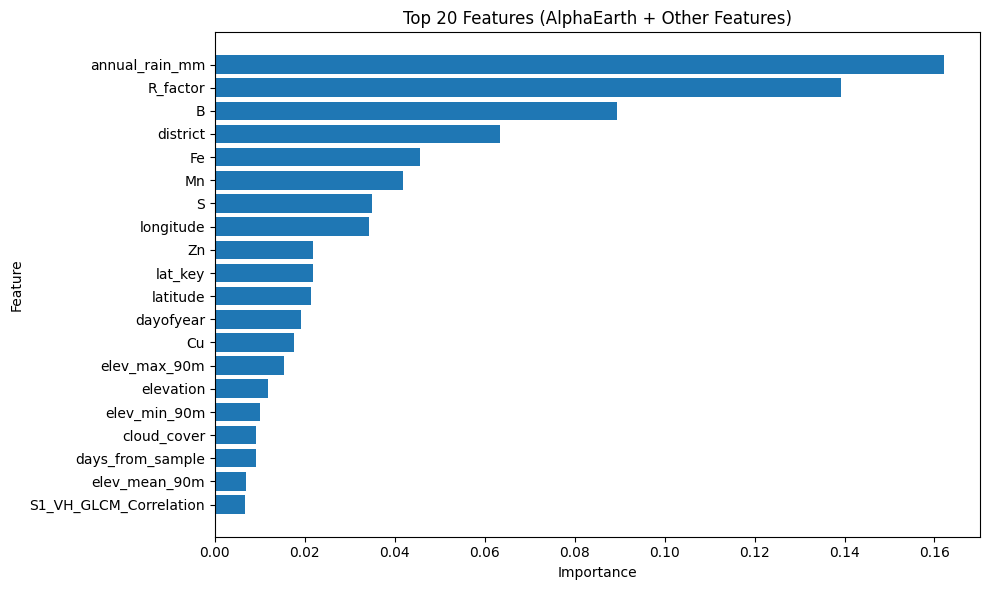

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

combined_importance = pd.DataFrame({
    "Feature": X_all.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(
    combined_importance.head(20)["Feature"][::-1],
    combined_importance.head(20)["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features (AlphaEarth + Other Features)")
plt.tight_layout()

plt.savefig("alphaearth_combined_importance.png", bbox_inches="tight")
plt.show()

with mlflow.start_run(run_id=combined_run_id):
    mlflow.log_artifact("alphaearth_combined_importance.png")

## Spatial CV

In [ ]:
# AlphaEarth embedding columns
embedding_cols = [c for c in embed_df.columns if c != 'fid']

# Alpha embeddings only
X_embed = X[embedding_cols]

# Combined features
X_combined = X.copy()

print("Embedding shape:", X_embed.shape)
print("Combined shape:", X_combined.shape)

Embedding shape: (281250, 65)
Combined shape: (281250, 207)


In [ ]:
from sklearn.cluster import KMeans
from sklearn.model_selection import GroupKFold

coords = df_embed[['latitude','longitude']]

n_groups = 5

groups = KMeans(
    n_clusters=n_groups,
    random_state=42,
    n_init=10
).fit_predict(coords)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def spatial_cv(X_used, y, groups):

    gkf = GroupKFold(n_splits=5)

    r2_scores = []
    rmse_scores = []

    fold = 1

    for train_idx, test_idx in gkf.split(
        X_used,
        y,
        groups
    ):

        X_train = X_used.iloc[train_idx]
        X_test = X_used.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        model = RandomForestRegressor(
            n_estimators=500,
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(X_test)

        r2 = r2_score(
            y_test,
            pred
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        )

        r2_scores.append(r2)
        rmse_scores.append(rmse)

        print(
            f"Fold {fold}: "
            f"R2={r2:.3f}, "
            f"RMSE={rmse:.3f}"
        )

        fold += 1

    return {
        "mean_r2": np.mean(r2_scores),
        "std_r2": np.std(r2_scores),
        "mean_rmse": np.mean(rmse_scores),
        "std_rmse": np.std(rmse_scores)
    }

On alphaearth only

In [ ]:
with mlflow.start_run(run_name="AlphaEarth_Embeddings_SpatialCV"):

    embed_results = spatial_cv(
        X_embed,
        y,
        groups
    )

    print("\nAlphaEarth Results")
    print(embed_results)

    mlflow.log_param("feature_set", "AlphaEarth_Embeddings")
    mlflow.log_param("n_features", X_embed.shape[1])
    mlflow.log_param("cv_type", "GroupKFold")
    mlflow.log_param("n_groups", n_groups)
    mlflow.log_param("n_estimators", 500)

    mlflow.log_metric("mean_R2", embed_results["mean_r2"])
    mlflow.log_metric("std_R2", embed_results["std_r2"])
    mlflow.log_metric("mean_RMSE", embed_results["mean_rmse"])
    mlflow.log_metric("std_RMSE", embed_results["std_rmse"])

Combined 

In [ ]:
with mlflow.start_run(run_name="AlphaEarth_Combined_SpatialCV"):

    combined_results = spatial_cv(
        X_combined,
        y,
        groups
    )

    print("\nCombined Results")
    print(combined_results)

    mlflow.log_param("feature_set", "AlphaEarth_Combined")
    mlflow.log_param("n_features", X_combined.shape[1])
    mlflow.log_param("cv_type", "GroupKFold")
    mlflow.log_param("n_groups", n_groups)
    mlflow.log_param("n_estimators", 500)

    mlflow.log_metric("mean_R2", combined_results["mean_r2"])
    mlflow.log_metric("std_R2", combined_results["std_r2"])
    mlflow.log_metric("mean_RMSE", combined_results["mean_rmse"])
    mlflow.log_metric("std_RMSE", combined_results["std_rmse"])